In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Colab setup
import os
import sys
from pathlib import Path

DRIVE_PROJECT = "Colab Notebooks/DDL-Diffusion/code"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q diffusers transformers datasets
    from google.colab import drive

    drive.mount("/content/drive")

    drive_root = Path("/content/drive/MyDrive")
    project_dir = drive_root / DRIVE_PROJECT

    if not (project_dir / "scheduler.py").is_file():
        raise RuntimeError(
            f"no scheduler.py under {project_dir} — upload the .py files to that "
            f"folder, or fix DRIVE_PROJECT above"
        )
    os.chdir(project_dir)
# else:
    # Local kernels don't agree on the starting cwd: Jupyter uses the notebook's
    # own directory, PyCharm/VS Code often use the project root. Walk up until we
    # find code/ so the bare `from scheduler import ...` imports and the relative
    # .pt paths resolve either way.
    # start = Path.cwd().resolve()
    # for base in (start, *start.parents):
    #     target = base if base.name == "code" else base / "code"
    #     if (target / "scheduler.py").is_file():
    #         os.chdir(target)
    #         break
    # else:
    #     raise RuntimeError(f"couldn't locate the repo's code/ directory from {start}")

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("colab:", IN_COLAB)
print("cwd  :", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
colab: True
cwd  : /content/drive/MyDrive/Colab Notebooks/DDL-Diffusion/code


In [ ]:
import torch
import datasets
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms as T
from diffusers import AutoencoderKL
from tqdm import tqdm
from transformers import CLIPTokenizer, CLIPTextModel

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
device

'cuda'

In [ ]:
SEED = 42   # single source of truth: seeds training and the preview sampler

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

In [ ]:
poke_data = datasets.load_dataset("diffusers/pokemon-gpt4-captions")

README.md:   0%|          | 0.00/2.21k [00:00<?, ?B/s]

data/train-00000-of-00001-a1df3b486d3a28(…): reconstructing file:   0%|          |  0.00B / 51.1MB            

data/train-00000-of-00001-a1df3b486d3a28(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/833 [00:00<?, ? examples/s]

In [ ]:
print(poke_data)
print(poke_data["train"][0])

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 833
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1280x1280 at 0x7AC3C0BB1AF0>, 'text': 'A cheerful Bulbasaur ready for its next Pokémon adventure.'}


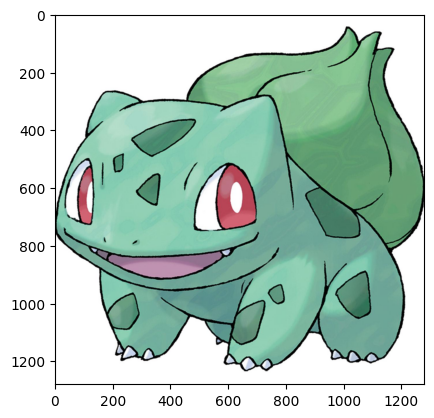

A cheerful Bulbasaur ready for its next Pokémon adventure.


In [ ]:
sample = poke_data["train"][0]
plt.imshow(sample["image"])
plt.show()
print(sample["text"])

In [ ]:
transforms = T.Compose([
    T.Resize(512),
    T.CenterCrop(512),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def preprocess(image):
    # Returns (3, 512, 512). Caller adds batch dim if needed.
    return transforms(image)

test_image = preprocess(sample["image"])
print(test_image.shape)
print(test_image.min(), test_image.max())

torch.Size([3, 512, 512])
tensor(-1.) tensor(1.)


In [ ]:
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
vae.requires_grad_(False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  335MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [ ]:
x = preprocess(poke_data["train"][0]["image"]).unsqueeze(0).to(device)

with torch.no_grad():
    latent = vae.encode(x).latent_dist.sample() * 0.18215

print(latent.shape)
print(latent.min(), latent.max(), latent.mean(), latent.std())

torch.Size([1, 4, 64, 64])
tensor(-2.2723, device='cuda:0') tensor(3.0827, device='cuda:0') tensor(0.5192, device='cuda:0') tensor(0.9315, device='cuda:0')


In [ ]:
# Encode the WHOLE dataset -> latents.pt
all_latents = []
batch_size = 16

for i in tqdm(range(0, len(poke_data["train"]), batch_size)):
    batch_items = poke_data["train"][i : i + batch_size]
    imgs = torch.stack([preprocess(im) for im in batch_items["image"]]).to(device)
    with torch.no_grad():
        latents = vae.encode(imgs).latent_dist.sample() * 0.18215
    all_latents.append(latents.cpu())  # .cpu() is critical — don't hoard on device

latents_tensor = torch.cat(all_latents, dim=0)
print(latents_tensor.shape)   # expect (~833, 4, 64, 64)
torch.save(latents_tensor, "latents.pt")


100%|██████████| 53/53 [03:09<00:00,  3.58s/it]

torch.Size([833, 4, 64, 64])


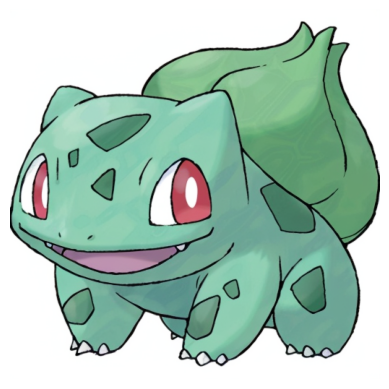

In [ ]:
# Decode a saved latent back to an image
latents = torch.load("latents.pt")
one = latents[0:1].to(device) / 0.18215      # undo the scaling
with torch.no_grad():
    decoded = vae.decode(one).sample          # (1, 3, 512, 512), values roughly in [-1, 1]
img = (decoded[0].cpu().clamp(-1, 1) + 1) / 2  # denormalize -> [0, 1]
img = img.permute(1, 2, 0).numpy()             # (H, W, C) for matplotlib
plt.imshow(img); plt.axis("off"); plt.show()

In [ ]:
CLIP_NAME = "openai/clip-vit-large-patch14"
tokenizer = CLIPTokenizer.from_pretrained(CLIP_NAME)
text_encoder = CLIPTextModel.from_pretrained(CLIP_NAME).to(device)
text_encoder.eval()
text_encoder.requires_grad_(False)

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
text_projection.weight                                         | UNEXPECTED |  | 
vision_model.encoder.

CLIPTextModel(
  (embeddings): CLIPTextEmbeddings(
    (token_embedding): Embedding(49408, 768)
    (position_embedding): Embedding(77, 768)
  )
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): QuickGELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (final_layer_norm): LayerNo

In [ ]:
# Verify shape (1, 77, 768).
test_caption = poke_data["train"][0]["text"]

tokens = tokenizer(
    test_caption,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
)
input_ids = tokens.input_ids.to(device)

with torch.no_grad():
    test_emb = text_encoder(input_ids).last_hidden_state

print(test_emb.shape)
print(test_emb.min(), test_emb.max(), test_emb.mean())

torch.Size([1, 77, 768])
tensor(-28.0912, device='cuda:0') tensor(33.0632, device='cuda:0') tensor(-0.1118, device='cuda:0')


In [ ]:
# Encode ALL captions -> embeddings.pt
# Row i of embeddings.pt -> row i of latents.pt.
all_captions = [row["text"] for row in poke_data["train"]]
assert len(all_captions) == latents_tensor.shape[0], "caption count must match latent count"

all_input_ids = tokenizer(
    all_captions,
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
).input_ids

all_embeddings = []
text_batch_size = 32
for i in tqdm(range(0, len(all_captions), text_batch_size)):
    batch_ids = all_input_ids[i : i + text_batch_size].to(device)
    with torch.no_grad():
        emb = text_encoder(batch_ids).last_hidden_state
    all_embeddings.append(emb.cpu())

embeddings_tensor = torch.cat(all_embeddings, dim=0)
print(embeddings_tensor.shape)   # (833, 77, 768)
torch.save(embeddings_tensor, "embeddings.pt")

100%|██████████| 27/27 [00:03<00:00,  7.86it/s]


torch.Size([833, 77, 768])


In [ ]:
# Encode the "" -> uncond_embedding.pt
# Used for Classifier-Free Guidance (CFG) during training and inference.
uncond_ids = tokenizer(
    "",
    padding="max_length",
    max_length=77,
    truncation=True,
    return_tensors="pt",
).input_ids.to(device)

with torch.no_grad():
    uncond_embedding = text_encoder(uncond_ids).last_hidden_state

print(uncond_embedding.shape)   # (1, 77, 768)
torch.save(uncond_embedding.cpu(), "uncond_embedding.pt")

torch.Size([1, 77, 768])


In [ ]:
# autoreload makes Jupyter pick up edits to .py files without restarting the kernel.
# %load_ext autoreload
# %autoreload 2
from scheduler import NoiseScheduler

In [ ]:
# alphas_cumprod[-1] should be tiny (well under 0.01). That means by t=T-1, almost no signal survives —
# x_T is essentially pure Gaussian noise, which is what we sample from at inference time.
# If alphas_cumprod[-1] is, say, 0.3, "noise" still has 30% of the
# original signal in it. The model never learns to denoise pure noise,
# and inference produces washed-out replicas instead of new images.

scheduler = NoiseScheduler().to(device)

print("betas                :", scheduler.betas.shape, "on", scheduler.betas.device)
print("alphas_cumprod[0]    =", scheduler.alphas_cumprod[0].item(),  "(should be ~ 1.0)")
print("alphas_cumprod[-1]   =", scheduler.alphas_cumprod[-1].item(), "(should be ~ 0.0)")
print("beta[0]              =", scheduler.betas[0].item())
print("beta[-1]             =", scheduler.betas[-1].item())

betas                : torch.Size([1000]) on cuda:0
alphas_cumprod[0]    = 0.9991499781608582 (should be ~ 1.0)
alphas_cumprod[-1]   = 0.0015789627796038985 (should be ~ 0.0)
beta[0]              = 0.0008500000112690032
beta[-1]             = 0.012000000104308128


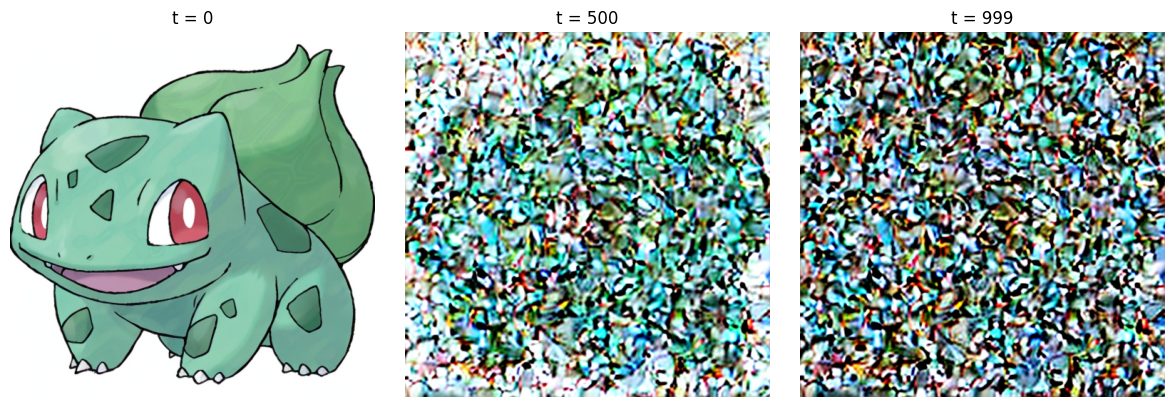

In [ ]:
# Noise one real Pokemon latent at three timesteps.
latents = torch.load("latents.pt")
x_0 = latents[0:1].to(device) # (1, 4, 64, 64), already scaled by 0.18215

noise = torch.randn_like(x_0)
timesteps_to_show = [0, 500, 999]

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(12, 4))

for ax, t_val in zip(axes, timesteps_to_show):
    # (B,)
    t = torch.full((1,), t_val, device=device, dtype=torch.long)

    # Add noise according to the schedule
    x_t = scheduler.q_sample(x_0, t, noise)

    # Decode back to pixel space
    with torch.no_grad():
        decoded = vae.decode(x_t / 0.18215).sample

    img = (decoded[0].cpu().clamp(-1, 1) + 1) / 2
    img = img.permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.set_title(f"t = {t_val}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Test the U-Net
# What we're checking:
#   1. No shape error
#   2. Output shape matches input shape: (B, 4, 64, 64) in, (B, 4, 64, 64) out.
#   3. Parameter count is in the sane range (low millions).

from unet import UNet
model = UNet().to(device)

B = 2
x = torch.randn(B, 4, 64, 64, device=device)
t = torch.randint(0, 1000, (B,), device=device, dtype=torch.long)
c = torch.randn(B, 77, 768, device=device)

with torch.no_grad():
    out = model(x, t, c)

print("Output shape :", out.shape) # (2, 4, 64, 64)
print("Output dtype :", out.dtype)
print("Output mean  :", out.mean().item())
print("Output std   :", out.std().item())

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")
print(f"Approx size in float32: {n_params * 4 / 1e6:.1f} MB")

Output shape : torch.Size([2, 4, 64, 64])
Output dtype : torch.float32
Output mean  : -0.04151838272809982
Output std   : 0.3509865999221802

Total parameters: 12,658,628
Approx size in float32: 50.6 MB


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

latents_tensor = torch.load("latents.pt")             # (833, 4, 64, 64) — VAE-encoded Pokemon
embeddings_tensor = torch.load("embeddings.pt")       # (833, 77, 768)   — CLIP-encoded captions
uncond_embedding = torch.load("uncond_embedding.pt")  # (1, 77, 768)     — CLIP-encoded ""

print("latents   :", latents_tensor.shape, latents_tensor.dtype)
print("embeddings:", embeddings_tensor.shape, embeddings_tensor.dtype)
print("uncond    :", uncond_embedding.shape, uncond_embedding.dtype)

uncond_embedding = uncond_embedding.to(device)
BATCH_SIZE = 4
train_dataset = TensorDataset(latents_tensor, embeddings_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)
print(f"\nbatches per epoch: {len(train_loader)}")

latents   : torch.Size([833, 4, 64, 64]) torch.float32
embeddings: torch.Size([833, 77, 768]) torch.float32
uncond    : torch.Size([1, 77, 768]) torch.float32

batches per epoch: 208


In [ ]:
from train import build_ema, make_optimizer, make_lr_schedule

# Same knobs as code/main.py's CLI flags.
NUM_EPOCHS = 200
WARMUP_STEPS = 1000
LR = 1e-4
WEIGHT_DECAY = 0.01
EMA_DECAY = 0.9999   # lower it (e.g. 0.999) for short runs so the EMA actually tracks the model
EMA_WARMUP = True    # False = fixed EMA_DECAY from step 0, which keeps the EMA near its random init for thousands of steps
AMP = "none"         # "none" | "bf16" | "fp16"  -> "bf16" on a Colab GPU

TOTAL_STEPS = NUM_EPOCHS * len(train_loader)   # used by the LR schedule for cosine decay

model = UNet().to(device)
noise_scheduler = NoiseScheduler().to(device)
ema_model = build_ema(model)
optimizer = make_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
lr_scheduler = make_lr_schedule(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS,
)

amp_dtype = {"none": None, "bf16": torch.bfloat16, "fp16": torch.float16}[AMP]

# fp16 gradients underflow to zero without loss scaling, so fp16 needs a GradScaler.
# bf16 has fp32's exponent range and must NOT use one.
scaler = None
if amp_dtype is torch.float16:
    if device == "cuda":
        scaler = torch.amp.GradScaler("cuda")
        print("fp16: GradScaler enabled")
    else:
        print(f"WARNING: fp16 on {device} has no GradScaler support, so gradients "
              f"will silently underflow. Use AMP = \"bf16\" instead.")

print(f"Trainable params : {sum(p.numel() for p in model.parameters()):,}")
print(f"Total steps      : {TOTAL_STEPS:,}  ({NUM_EPOCHS} epochs × {len(train_loader)} batches)")
print(f"Warmup steps     : {WARMUP_STEPS}")
print(f"Peak LR          : {LR}")
print(f"AMP              : {AMP}")

Trainable params : 12,658,628
Total steps      : 41,600  (200 epochs × 208 batches)
Warmup steps     : 1000
Peak LR          : 0.0001
AMP              : none


In [ ]:
from train import train_step

smoke_losses = []
data_iter = iter(train_loader)

for i in range(5):
    x_0, context = next(data_iter)
    x_0 = x_0.to(device)
    context = context.to(device)
    loss = train_step(
        model=model,
        ema_model=ema_model,
        noise_scheduler=noise_scheduler,
        optimizer=optimizer,
        lr_scheduler=lr_scheduler,
        x_0=x_0,
        context=context,
        uncond_embedding=uncond_embedding,
        ema_decay=EMA_DECAY,
        amp_dtype=amp_dtype,
        scaler=scaler,
        step=i if EMA_WARMUP else None,
    )
    smoke_losses.append(loss)
    print(f"step {i}: loss = {loss:.4f}")

# Test passed if losses are finite (no NaN) and trending downward.
# Re-run the cell above before real training so the optimizer/LR schedule start clean.

step 0: loss = 1.0482
step 1: loss = 1.0568
step 2: loss = 1.0550
step 3: loss = 1.0598
step 4: loss = 1.0528


In [ ]:
from pathlib import Path

from tqdm.auto import tqdm
from train import train_step, save_checkpoint, load_checkpoint

# These are relative to cwd, which on Colab is your mounted Drive folder — so
# checkpoints and previews land in Drive and survive a runtime disconnect.
# Checkpoints are ~150 MB each and Drive writes are slow, so keep
# CHECKPOINT_EVERY coarse rather than saving every epoch.
CHECKPOINT_DIR = "checkpoints"
CHECKPOINT_EVERY = 25            # save every N epochs
LOG_EVERY = 50                   # update tqdm postfix every N steps
RESUME_PATH = None               # path to a checkpoint .pt, or None to start fresh

PREVIEW = False                  # True -> DDIM sample every PREVIEW_EVERY epochs, so you SEE progress
PREVIEW_EVERY = 10
PREVIEW_STEPS = 50
PREVIEW_CFG = 7.5
PREVIEW_ROW = 0                  # which embedding row to use as the preview prompt
PREVIEW_DIR = "previews"


def make_preview(epoch: int) -> None:
    """One DDIM sample from the EMA model: save a PNG and show it inline."""
    from sample import sample_to_image
    from torchvision.utils import save_image

    # SEED comes from the seeding cell near the top, so previews stay comparable across epochs.
    g = torch.Generator(device=device).manual_seed(SEED)
    img = sample_to_image(
        model=ema_model,
        scheduler=noise_scheduler,
        vae=vae,
        cond_emb=embeddings_tensor[PREVIEW_ROW : PREVIEW_ROW + 1].to(device),
        uncond_emb=uncond_embedding,
        method="ddim",
        guidance_scale=PREVIEW_CFG,
        num_steps=PREVIEW_STEPS,
        generator=g,
    )[0].cpu()   # (3, 512, 512) in [0, 1]

    out_path = Path(PREVIEW_DIR) / f"epoch_{epoch}.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    save_image(img, str(out_path))
    print(f"saved preview -> {out_path}")

    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(f"epoch {epoch}")
    plt.axis("off")
    plt.show()


start_step = 0
start_epoch = 0
loss_history: list[float] = []

if RESUME_PATH is not None:
    start_step, start_epoch, loss_history = load_checkpoint(
        RESUME_PATH, model, ema_model, optimizer, lr_scheduler,
        map_location=device, scaler=scaler,
    )
    model.to(device)
    ema_model.to(device)
    print(f"resumed from {RESUME_PATH}: step={start_step}, epoch={start_epoch}")

global_step = start_step
running_loss = 0.0
running_count = 0

for epoch in range(start_epoch, NUM_EPOCHS):

    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{NUM_EPOCHS}", leave=False)
    for x_0, context in pbar:
        x_0 = x_0.to(device)
        context = context.to(device)

        loss = train_step(
            model=model,
            ema_model=ema_model,
            noise_scheduler=noise_scheduler,
            optimizer=optimizer,
            lr_scheduler=lr_scheduler,
            x_0=x_0,
            context=context,
            uncond_embedding=uncond_embedding,
            ema_decay=EMA_DECAY,
            amp_dtype=amp_dtype,
            scaler=scaler,
            step=global_step if EMA_WARMUP else None,
        )

        loss_history.append(loss)
        running_loss += loss
        running_count += 1
        global_step += 1

        if global_step % LOG_EVERY == 0:
            avg = running_loss / running_count
            pbar.set_postfix(
                loss=f"{avg:.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )
            running_loss = 0.0
            running_count = 0

    if (epoch + 1) % CHECKPOINT_EVERY == 0 or epoch + 1 == NUM_EPOCHS:
        ckpt_path = f"{CHECKPOINT_DIR}/epoch_{epoch + 1}.pt"
        save_checkpoint(
            ckpt_path, model, ema_model, optimizer, lr_scheduler,
            step=global_step, epoch=epoch + 1, loss_history=loss_history,
            scaler=scaler,
        )
        print(f"saved checkpoint -> {ckpt_path}")

    if PREVIEW and (epoch + 1) % PREVIEW_EVERY == 0:
        make_preview(epoch + 1)

print("training complete.")

epoch 1/200:   0%|          | 0/208 [00:00<?, ?it/s]

epoch 2/200:   0%|          | 0/208 [00:00<?, ?it/s]

epoch 3/200:   0%|          | 0/208 [00:00<?, ?it/s]

epoch 4/200:   0%|          | 0/208 [00:00<?, ?it/s]

epoch 5/200:   0%|          | 0/208 [00:00<?, ?it/s]

...

epoch 197/200:   0%|          | 0/208 [00:00<?, ?it/s]

epoch 198/200:   0%|          | 0/208 [00:00<?, ?it/s]

epoch 199/200:   0%|          | 0/208 [00:00<?, ?it/s]

epoch 200/200:   0%|          | 0/208 [00:00<?, ?it/s]

saved checkpoint -> checkpoints/epoch_200.pt
training complete.


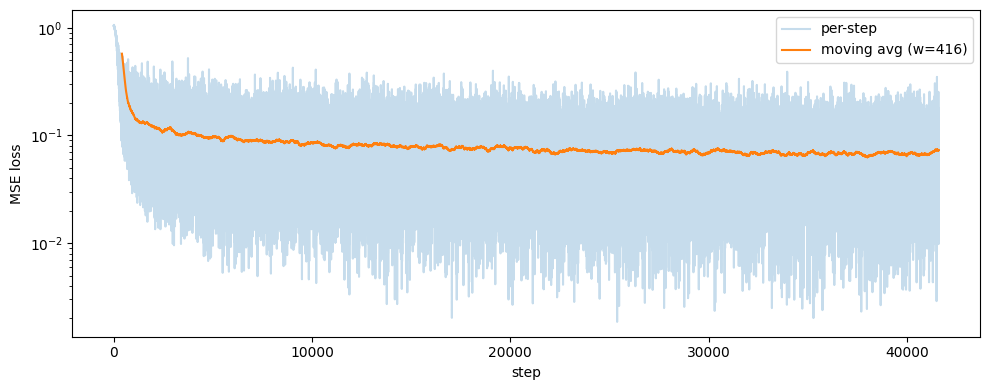

In [ ]:
# Plot the loss curve
losses = np.array(loss_history)
window = max(1, len(losses) // 100)
moving = np.convolve(losses, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 4))
plt.plot(losses, alpha=0.25, label="per-step")
plt.plot(np.arange(window - 1, len(losses)), moving, label=f"moving avg (w={window})")

plt.xlabel("step")
plt.ylabel("MSE loss")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

## Inference & evaluation checks

The training curve above says *nothing broke*. It cannot say whether the model
learned to use the text, or whether it generates anything that looks like a
Pokemon. Everything below answers those questions from a saved checkpoint.

Order matters — each block gets cheaper to interpret if the one before it passed:

1. **Checkpoint + EMA sanity** — is the EMA a real average, or still near its random init?
2. **Loss binned by timestep** — *where* on the schedule did the model learn?
3. **Conditioning check** — does swapping the caption change the loss at all?
4. **Samples** — the actual images.
5. **CFG sweep** — does guidance steer, or just saturate?
6. **Sampler cross-check** — do DDIM and DDPM agree?
7. **Memorization check** — generator, or 833-image lookup table?

Requires the cells above for `vae`, `tokenizer`, `text_encoder`, `latents_tensor`,
`embeddings_tensor` and `uncond_embedding`. It does **not** require the training
cell to have run in this session — it loads weights from disk.

> **Known issue this run inherits — non-zero terminal SNR.**
> `alphas_cumprod[-1] = 0.00158`, so `sqrt(alphas_cumprod[-1]) = 0.0397`. At `t=999`
> training still leaks `0.0397 x x_0` into `x_t`. Because the training latents have
> per-channel means of `[+1.50, +0.86, +0.03, -0.64]`, that leak is a per-channel DC
> offset of about `[+0.060, +0.034, +0.001, -0.025]` — detectable at roughly 4 sigma
> once you average over the 4096 spatial positions of a channel.
>
> Inference starts from `torch.randn`, whose per-channel mean is exactly 0. So the
> very first denoising step sees a slightly off-distribution input. This is the
> flaw described in *Common Diffusion Noise Schedules and Sample Steps are Flawed*
> (Lin et al.), and stock Stable Diffusion has it worse (`scaled_linear` gives
> `alphas_cumprod[-1] = 0.0047`). Mild here, but it is a real cause of shifted
> brightness/colour in samples — worth ruling out before blaming the model.

In [ ]:
# 1. Load a checkpoint and check the EMA is usable.
import torch.nn.functional as F

from unet import UNet
from scheduler import NoiseScheduler
from sample import sample_ddim, sample_ddpm, latents_to_images

# TODO: point this at the checkpoint you want to evaluate.
CKPT_PATH = "checkpoints/epoch_200.pt"

ckpt = torch.load(CKPT_PATH, map_location=device)
print(f"checkpoint : {CKPT_PATH}")
print(f"epoch      : {ckpt['epoch']}")
print(f"step       : {ckpt['step']}")
print(f"loss_hist  : {len(ckpt.get('loss_history', []))} entries")

# Rebuilt here so this whole section works in a fresh runtime without re-running training.
# NoiseScheduler holds nothing but deterministic constants, so this is identical to
# the instance training used.
noise_scheduler = NoiseScheduler().to(device)

# Two models so we can compare the EMA against the live weights.
live_model = UNet().to(device)
live_model.load_state_dict(ckpt["model"])
live_model.eval()

eval_ema = UNet().to(device)
eval_ema.load_state_dict(ckpt["ema_model"])
eval_ema.eval()

# We sample from the EMA, so if the EMA never caught up to the live model its images
# are noise no matter how good the loss curve looked. With EMA_DECAY=0.9999 and the
# warmup ramp min(decay, (1+step)/(10+step)), the ramp is still the binding term at
# step 41,600 -> effective decay 0.99978, averaging window ~4.6k steps. So the two
# should be close. A relative delta near 1.0 means the EMA is still near random init.
live_flat = torch.cat([p.flatten() for p in live_model.parameters()])
ema_flat = torch.cat([p.flatten() for p in eval_ema.parameters()])
rel_delta = (ema_flat - live_flat).norm().item() / live_flat.norm().item()

print(f"\n|live|              = {live_flat.norm().item():.2f}")
print(f"|ema|               = {ema_flat.norm().item():.2f}")
print(f"|ema - live|/|live| = {rel_delta:.4f}   (want << 1; ~1 = EMA still near init)")

In [ ]:
# 2. Loss binned by timestep — the diagnostic the aggregate curve hides.
#
# The training curve averages over uniformly sampled t, so most of its per-step
# variance is just "which t did this step draw". At t~0 the latent is nearly clean
# and the loss is ~0.002; at t~999 the input is pure noise and even a perfect model
# scores close to 1. That is the whole 0.002-0.5 band in the plot above, and it means
# a FLAT AVERAGE CAN HIDE real progress in the mid-t range that decides image
# structure. So: fix the noise, sweep t, and look at the profile instead.
#
# Reference line: a model that always predicts zero noise scores E[eps^2] = 1.0 at
# every t. Any bin sitting near 1.0 is a bin where the model learned nothing.
# Note these numbers run in eval mode (dropout off), so they read LOWER than the
# ~0.07 training plateau, which included ResNetBlock dropout at p=0.1.

EVAL_N = 256           # latents per timestep
N_BINS = 20

cpu_gen = torch.Generator().manual_seed(1234)
eval_idx = torch.randperm(latents_tensor.shape[0], generator=cpu_gen)[:EVAL_N]
eval_x0 = latents_tensor[eval_idx].to(device)
eval_ctx = embeddings_tensor[eval_idx].to(device)
# One fixed noise draw, reused for every bin and every model, so differences are
# never just resampling luck.
eval_noise = torch.randn(eval_x0.shape, generator=cpu_gen).to(device)


@torch.no_grad()
def loss_at_t(m, t_val, x0=None, ctx=None, noise=None, batch=32):
    """Mean per-element MSE at one fixed timestep, in eval mode."""
    x0 = eval_x0 if x0 is None else x0
    ctx = eval_ctx if ctx is None else ctx
    noise = eval_noise if noise is None else noise

    total, n = 0.0, 0
    for i in range(0, x0.shape[0], batch):
        xb, cb, nb = x0[i : i + batch], ctx[i : i + batch], noise[i : i + batch]
        t = torch.full((xb.shape[0],), t_val, device=device, dtype=torch.long)
        x_t = noise_scheduler.q_sample(xb, t, nb)
        eps = m(x_t, t, cb)
        total += F.mse_loss(eps, nb, reduction="sum").item()
        n += nb.numel()
    return total / n


bin_ts = [int((i + 0.5) * noise_scheduler.T / N_BINS) for i in range(N_BINS)]
ema_curve, live_curve = [], []

for t_val in bin_ts:
    l_ema = loss_at_t(eval_ema, t_val)
    l_live = loss_at_t(live_model, t_val)
    ema_curve.append(l_ema)
    live_curve.append(l_live)
    print(f"t={t_val:4d}  ema={l_ema:.4f}  live={l_live:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(bin_ts, ema_curve, "o-", label="EMA")
plt.plot(bin_ts, live_curve, "s--", label="live", alpha=0.7)
plt.axhline(1.0, color="red", ls=":", label="predict-zero baseline")
plt.xlabel("timestep t")
plt.ylabel("MSE loss (eval mode)")
plt.title("Denoising loss vs timestep")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# 3. Is the model actually using the text?
#
# THE most common silent failure in a from-scratch conditional diffusion model:
# the cross-attention layers learn nothing, the U-Net becomes an unconditional
# denoiser, and CFG at inference just amplifies noise. The loss curve looks
# completely normal when this happens.
#
# Test: same latents, same noise, same t — only the caption changes.
#   matched  = each latent with its own caption
#   shuffled = each latent with someone else's caption
#   uncond   = the "" embedding
#
# If matched < shuffled, conditioning carries signal. If the three columns are
# equal to ~3 decimals, cross-attention is dead and no CFG value will help.
# Expect the gap to be largest at mid/low t, where the caption still has room to
# change the outcome — at t~999 there is nothing to condition.

shuf = torch.randperm(EVAL_N, generator=torch.Generator().manual_seed(7))
# Guard against a fixed point mapping a row back to its own caption.
assert (shuf == torch.arange(EVAL_N)).sum().item() < EVAL_N * 0.05
shuffled_ctx = eval_ctx[shuf.to(eval_ctx.device)]
uncond_ctx = uncond_embedding.to(device).expand(EVAL_N, -1, -1)

print(f"{'t':>5}  {'matched':>9}  {'shuffled':>9}  {'uncond':>9}  {'shuf-match':>11}")
cond_gaps = []
for t_val in [50, 150, 300, 500, 700, 900]:
    l_match = loss_at_t(eval_ema, t_val)
    l_shuf = loss_at_t(eval_ema, t_val, ctx=shuffled_ctx)
    l_unc = loss_at_t(eval_ema, t_val, ctx=uncond_ctx)
    cond_gaps.append(l_shuf - l_match)
    print(f"{t_val:5d}  {l_match:9.4f}  {l_shuf:9.4f}  {l_unc:9.4f}  {l_shuf - l_match:+11.4f}")

best_gap = max(cond_gaps)
print(f"\nlargest shuffled-minus-matched gap: {best_gap:+.4f}")
if best_gap < 1e-3:
    print("=> CONDITIONING IS DEAD. The caption does not change the prediction.")
    print("   CFG will do nothing useful. Fix training before reading anything into the samples.")
elif best_gap < 1e-2:
    print("=> WEAK conditioning. Text barely registers; expect prompt-insensitive samples.")
else:
    print("=> Conditioning is live. The model does read the caption.")

In [ ]:
# 4. Helpers: encode arbitrary prompts, and show a row of decoded samples.


@torch.no_grad()
def encode_prompt(prompts):
    """list[str] -> (B, 77, 768) CLIP embeddings, same pipeline as the training data."""
    if isinstance(prompts, str):
        prompts = [prompts]
    ids = tokenizer(
        prompts,
        padding="max_length",
        max_length=77,
        truncation=True,
        return_tensors="pt",
    ).input_ids.to(device)
    return text_encoder(ids).last_hidden_state


@torch.no_grad()
def generate(cond_emb, method="ddim", num_steps=50, guidance_scale=7.5, eta=0.0, seed=42):
    """Sample latents and return (images in [0,1], raw latents). Uses the EMA model."""
    g = torch.Generator(device=device).manual_seed(seed)
    if method == "ddim":
        lat = sample_ddim(
            eval_ema, noise_scheduler, cond_emb, uncond_embedding.to(device),
            guidance_scale=guidance_scale, num_steps=num_steps, eta=eta, generator=g,
        )
    else:
        lat = sample_ddpm(
            eval_ema, noise_scheduler, cond_emb, uncond_embedding.to(device),
            guidance_scale=guidance_scale, num_steps=num_steps, generator=g,
        )
    return latents_to_images(lat, vae).cpu(), lat


def show_row(images, titles, suptitle=None, wrap=28):
    """images: (B, 3, H, W) in [0, 1]."""
    n = images.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.8))
    axes = [axes] if n == 1 else list(axes)
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
        wrapped = "\n".join(str(title)[i : i + wrap] for i in range(0, min(len(str(title)), wrap * 3), wrap))
        ax.set_title(wrapped, fontsize=8)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=11)
    plt.tight_layout()
    plt.show()


def latent_stats(name, lat):
    """Compare generated latent statistics against the training latents.

    IMPORTANT — the training latents are NOT zero-mean / unit-std per channel:

        overall   mean +0.4403   std 1.1226
        per-chan  mean [+1.503, +0.862, +0.032, -0.636]
        per-chan  std  [ 0.731,  0.984,  0.604,  0.735]

    That per-channel offset is a known property of the SD VAE latent space, and
    0.18215 is a single global scalar that only normalizes the OVERALL std. So a
    generated latent that comes out at mean ~0.00 / std ~1.00 is WRONG, not right —
    it decodes to off-colour mush. Match the numbers above instead.

    A generated std much below the reference is the classic "flat gray output"
    failure, and it is invisible in the loss curve.
    """
    pc_mean = lat.mean(dim=(0, 2, 3)).tolist()
    pc_std = lat.std(dim=(0, 2, 3)).tolist()
    print(f"{name:22s} mean={lat.mean().item():+.4f} std={lat.std().item():.4f}  "
          f"per-chan mean={[round(v, 2) for v in pc_mean]}  std={[round(v, 2) for v in pc_std]}")


latent_stats("TRAINING (reference)", latents_tensor)

In [ ]:
# 5. THE inference check: sample from captions the model actually trained on.
#
# This is the easiest possible ask — these exact captions were seen ~200 times each.
# If these do not look like Pokemon, nothing else will.

N_SHOW = 4
show_rows = list(range(N_SHOW))
captions = [poke_data["train"][i]["text"] for i in show_rows]
cond = embeddings_tensor[show_rows].to(device)

imgs, lats = generate(cond, method="ddim", num_steps=50, guidance_scale=7.5, seed=SEED)
latent_stats("generated (cfg 7.5)", lats)
show_row(imgs, captions, suptitle="DDIM 50 steps, CFG 7.5 — training captions")

# Side by side with the real image each caption came from, as a target to compare against.
real = torch.stack([preprocess(poke_data["train"][i]["image"]) for i in show_rows])
show_row((real + 1) / 2, captions, suptitle="Ground truth for the same captions")

In [ ]:
# 6. CFG sweep — same seed, same prompt, varying guidance.
#
# w=1.0 is plain conditional sampling (no guidance). Higher w pushes harder toward
# the caption at the cost of saturation and artifacts. 7.5 is the Stable Diffusion
# default, but SD is a 860M-param model trained on billions of images — a 12.6M-param
# model trained on 833 images usually oversaturates well before 7.5, and w in the
# 2-4 range tends to look far better. Read this row before trusting the CFG 7.5
# images above.
#
# Also a conditioning check by another route: if every column here looks IDENTICAL,
# eps_cond == eps_uncond and the guidance term is doing nothing.

CFG_ROW = 0
cfg_caption = poke_data["train"][CFG_ROW]["text"]
cfg_cond = embeddings_tensor[CFG_ROW : CFG_ROW + 1].to(device)

print(f"prompt: {cfg_caption}\n")
scales = [1.0, 2.0, 4.0, 7.5, 15.0]
cfg_imgs = []
for w in scales:
    img, lat = generate(cfg_cond, method="ddim", num_steps=50, guidance_scale=w, seed=SEED)
    latent_stats(f"cfg {w}", lat)
    cfg_imgs.append(img[0])

show_row(torch.stack(cfg_imgs), [f"CFG {w}" for w in scales], suptitle="Guidance sweep (same seed)")

In [ ]:
# 7. Sampler cross-check: DDIM step count, and DDIM vs DDPM.
#
# Both samplers reverse the SAME trained model, so they should produce recognisably
# similar images. Disagreement localises the bug:
#   - DDPM(1000) fine but DDIM(50) broken -> the strided alpha_bar grid math is wrong
#   - both broken but per-timestep loss looked healthy -> a sampler bug, not a training bug
#   - DDIM(50) noticeably worse than DDIM(250) -> just discretization error, expected
#
# DDPM at 1000 steps is 1000 U-Net calls at batch 2 (CFG doubles the batch), so this
# cell is the slow one in this section.

sweep_cond = embeddings_tensor[0:1].to(device)
CFG = 4.0   # TODO: set this to whatever the sweep in the previous cell showed was best.

variants = [
    ("ddim", 25), ("ddim", 50), ("ddim", 250), ("ddpm", 1000),
]

sweep_imgs, sweep_titles = [], []
for method, steps in variants:
    img, lat = generate(sweep_cond, method=method, num_steps=steps, guidance_scale=CFG, seed=SEED)
    latent_stats(f"{method} {steps}", lat)
    sweep_imgs.append(img[0])
    sweep_titles.append(f"{method.upper()} {steps} steps")

show_row(torch.stack(sweep_imgs), sweep_titles, suptitle=f"Sampler comparison (CFG {CFG}, same seed)")

In [ ]:
# 8. Novel prompts — the only test of generalization the samples can give.
#
# Captions the model has never seen. 833 images is far too few to expect real
# compositional generalization, so treat anything coherent here as a bonus. The
# useful signal is DIFFERENCE: if a red fire dragon and a blue water turtle come out
# looking the same, the model collapsed to a prompt-independent average.

novel = [
    "a red fire dragon pokemon with large wings",
    "a blue water turtle pokemon with a hard shell",
    "a small yellow electric mouse pokemon",
    "a green grass pokemon with a flower on its back",
]
novel_cond = encode_prompt(novel)

novel_imgs, novel_lats = generate(novel_cond, method="ddim", num_steps=50, guidance_scale=CFG, seed=SEED)
latent_stats("generated (novel)", novel_lats)
show_row(novel_imgs, novel, suptitle=f"Unseen prompts (DDIM 50, CFG {CFG})")

# Pairwise latent distance between the four samples. Near-zero off-diagonal entries
# mean the prompt is being ignored and every sample collapsed to the same output.
flat = novel_lats.flatten(1)
dist = torch.cdist(flat, flat).cpu()
print("\npairwise latent L2 between samples:")
print(dist.numpy().round(2))
print(f"mean off-diagonal distance: {dist[~torch.eye(len(novel), dtype=bool)].mean().item():.2f}")

In [ ]:
# 9. Memorization check — generator, or an 833-image lookup table?
#
# 833 images x 200 epochs on a 12.6M-param model is deep in memorization territory,
# and NOTHING in the loss curve can tell you which one you got. So: for each
# generated latent, find the nearest training latent and look at them together.
#
# Measured latent L2 between two DIFFERENT training images, over all 833 x 832 pairs:
#   mean 126.98   median 126.17   p1 98.69   min 18.79   max 204.97
#
# Note the min is only 18.79 — the dataset itself contains near-duplicates (alternate
# Pokemon forms, recolours), so "closer than any two training images" is NOT a usable
# threshold here. Two tiers instead:
#
#   dist < 98.69  (p1)  -> suspicious: closer than 99% of genuine distinct pairs.
#                          Inspect the pair visually before drawing conclusions.
#   dist < 18.79  (min) -> unambiguous copy: closer than the two nearest real images.

SUSPICIOUS = 98.69
DEFINITE_COPY = 18.79


@torch.no_grad()
def nearest_training_latent(gen_lat):
    """Return (indices, distances, full distance matrix) over the training latents."""
    gen = gen_lat.flatten(1).cpu()
    train = latents_tensor.flatten(1)
    d = torch.cdist(gen, train)                     # (n_gen, 833)
    dist, idx = d.min(dim=1)
    return idx, dist, d


gen_imgs, gen_lats = generate(embeddings_tensor[0:4].to(device), num_steps=50, guidance_scale=CFG, seed=SEED)
nn_idx, nn_dist, _ = nearest_training_latent(gen_lats)

# Recompute the baseline rather than trusting the numbers in the comment above.
train_flat = latents_tensor.flatten(1)
train_d = torch.cdist(train_flat, train_flat)
off_diag = train_d[~torch.eye(train_flat.shape[0], dtype=torch.bool)]
print(f"train-vs-train latent L2: mean {off_diag.mean():.2f}  median {off_diag.median():.2f}  "
      f"p1 {off_diag.quantile(0.01):.2f}  min {off_diag.min():.2f}\n")

for i, (j, d) in enumerate(zip(nn_idx.tolist(), nn_dist.tolist())):
    if d < DEFINITE_COPY:
        flag = "  <-- COPY"
    elif d < SUSPICIOUS:
        flag = "  <-- suspicious, inspect"
    else:
        flag = ""
    print(f"sample {i}: nearest train idx {j:3d}  dist {d:7.2f}"
          f"  ({d / off_diag.median().item():.2f}x median){flag}")

nn_real = torch.stack([preprocess(poke_data["train"][j]["image"]) for j in nn_idx.tolist()])
show_row(gen_imgs, [f"generated {i}" for i in range(len(nn_idx))], suptitle="Generated")
show_row((nn_real + 1) / 2, [f"nearest train #{j}" for j in nn_idx.tolist()],
         suptitle="Nearest training image (latent L2)")